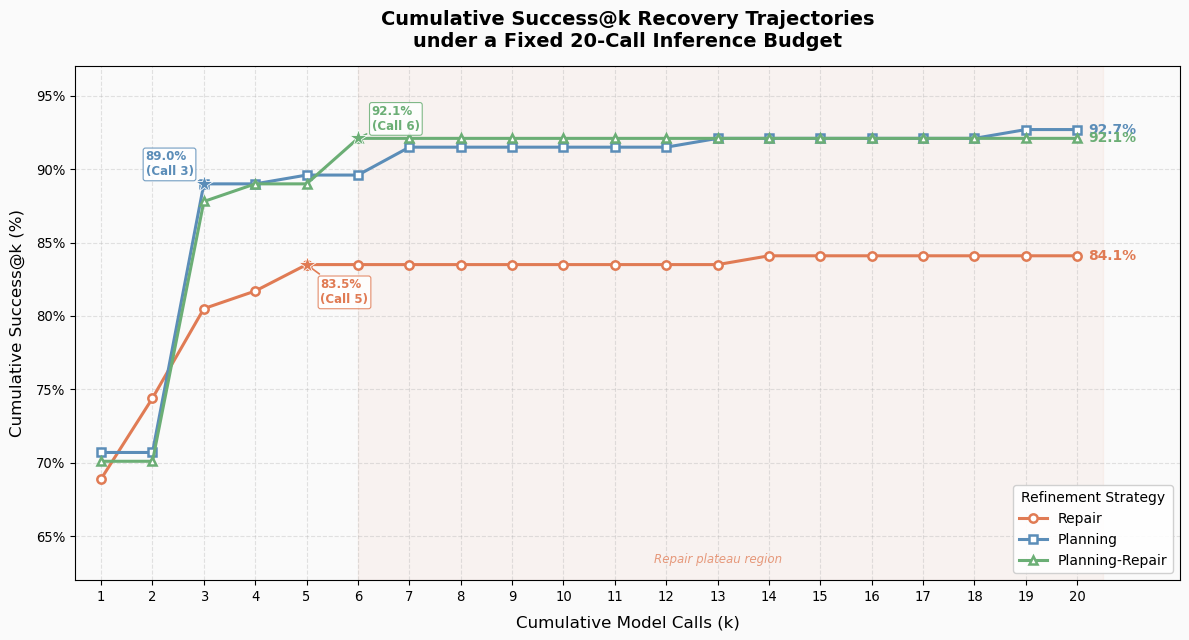

저장 완료


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 데이터 (0-indexed, x축은 1-indexed로 표시) ───────────────────────────
data = {
    "Repair": [
        68.9, 74.4, 80.5, 81.7, 83.5, 83.5, 83.5, 83.5, 83.5, 83.5,
        83.5, 83.5, 83.5, 84.1, 84.1, 84.1, 84.1, 84.1, 84.1, 84.1,
    ],
    "Planning": [
        70.7, 70.7, 89.0, 89.0, 89.6, 89.6, 91.5, 91.5, 91.5, 91.5,
        91.5, 91.5, 92.1, 92.1, 92.1, 92.1, 92.1, 92.1, 92.7, 92.7,
    ],
    "Planning-Repair": [
        70.1, 70.1, 87.8, 89.0, 89.0, 92.1, 92.1, 92.1, 92.1, 92.1,
        92.1, 92.1, 92.1, 92.1, 92.1, 92.1, 92.1, 92.1, 92.1, 92.1,
    ],
}

# x축: 1-indexed (1~20)
steps = list(range(1, 21))

STYLE = {
    "Repair":          {"color": "#E07B54", "marker": "o"},
    "Planning":        {"color": "#5B8DB8", "marker": "s"},
    "Planning-Repair": {"color": "#6BAE75", "marker": "^"},
}

# ── Figure ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# ── Repair plateau 구간 음영 (step 5 이후, 1-indexed → x=6부터) ───────────
ax.axvspan(6, 20.5, alpha=0.06, color="#E07B54", zorder=1)
ax.text(13, 63.2, "Repair plateau region", ha="center", fontsize=8.5,
        color="#E07B54", alpha=0.75, style="italic")

# ── 라인 플롯 ────────────────────────────────────────────────────────────
for label, values in data.items():
    s = STYLE[label]
    ax.plot(
        steps, values,
        color=s["color"],
        linestyle="-",
        linewidth=2.2,
        marker=s["marker"],
        markersize=6,
        markerfacecolor="white",
        markeredgewidth=1.8,
        markeredgecolor=s["color"],
        label=label,
        zorder=3,
    )
    # 라인 끝 최종값 레이블
    ax.annotate(
        f"{values[-1]:.1f}%",
        xy=(20, values[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=s["color"],
    )

# ── milestone 강조 ───────────────────────────────────────────────────────
# 글 기준:
#   Repair        → 5번째 model call = step 5 (1-indexed)
#   Planning      → 3번째 model call = step 3 (1-indexed)
#   Planning-Repair → 6번째 model call = step 6 (1-indexed)
milestones = [
    ("Repair",          5,  83.5, "83.5%\n(Call 5)",   ( 10, -20)),
    ("Planning",        3,  89.0, "89.0%\n(Call 3)",   (-42,  14)),
    ("Planning-Repair", 6,  92.1, "92.1%\n(Call 6)",   ( 10,  14)),
]

for label, step, val, text, xytext in milestones:
    color = STYLE[label]["color"]
    ax.plot(step, val, marker="*", markersize=13,
            color=color, zorder=5, markeredgecolor="white", markeredgewidth=0.6)
    ax.annotate(
        text,
        xy=(step, val),
        xytext=xytext,
        textcoords="offset points",
        fontsize=8.5,
        color=color,
        fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=color, lw=1.2),
        va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.85, lw=0.8),
    )

# ── 축 설정 ──────────────────────────────────────────────────────────────
ax.set_xlim(0.5, 22)
ax.set_ylim(62, 97)
ax.set_xticks(steps)
ax.set_xticklabels([str(s) for s in steps])
ax.set_xlabel("Cumulative Model Calls (k)", fontsize=12, labelpad=8)
ax.set_ylabel("Cumulative Success@k (%)", fontsize=12, labelpad=8)
ax.set_title(
    "Cumulative Success@k Recovery Trajectories\nunder a Fixed 20-Call Inference Budget",
    fontsize=14, fontweight="bold", pad=14
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(True, linestyle="--", alpha=0.35, zorder=0)
ax.tick_params(axis="both", labelsize=9.5)

# ── 범례 ────────────────────────────────────────────────────────────────
ax.legend(
    title="Refinement Strategy",
    title_fontsize=10,
    fontsize=10,
    loc="lower right",
    framealpha=0.9,
    edgecolor="#CCCCCC",
)

plt.tight_layout()
plt.savefig("./archive/section3_recovery_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료")